## 앙상블 학습

## 앙상블 학습 (Ensemble Learning) 개요

### 앙상블 학습을 통한 분류   

- 여러 개의 분류기(Classifier)을 사용해서 예측 결합함으로써 보다 정확한 최종 예측을 도출하는 기법
- 단일 분류기 사용 때보다 신뢰성이 높은 예측값을 얻을 수 있음
- 쉽고 편하면서도 강력한 성능 보유
- 대부분의 정형 데이터 분류 시 뛰어난 성능을 나타냄
- 이미지, 영상, 음성 등의 비정형 데이터 분류 : 딥러닝 성능 뛰어남

### 대표적인 앙상블 알고리즘
- 랜덤포레스트
- 그레디언트 부스팅

#### 최신 앙상블 알고리즘
- XGBoost 
- LightBGM : XGBoot 예측성능 유사하면서 수행속도 훨씬 빠름
- Stacking : 메타모델 수립

### 앙상블 학습결과(예측) 결합하는 방법

#### 앙상블 모델을 구성하는 방법
- 보팅(Voting) : 동시학습
- 배깅(Bagging) : 동시학습
- 부스팅(Boosting) : 순차적 학습
    - 모델은 이전 모델의 결과를 가중치로 적용시켜서 현재 학습에 반영

보팅(Voting) : 여러 분류기가 투표를 통해 최종 예측 결과를 결정하는 방식
- 일반적으로 서로 다른 알고리즘을 가진 분류기를 결합
- 모든 분류기가 동일한 데이터 전체를 학습

배깅(Bagging) : 보팅과 동일하게 여러 분류기가 투표를 통해 최종 예측 결과를 결정하는 방식
- 각각의 분류기가 모두 같은 유형의 알고리즘 기반이지만, 
- 샘플링을 서로 다르게 하면서 학습 수행
- 대표적인 배깅 방식 : 랜덤 포레스트 알고리즘

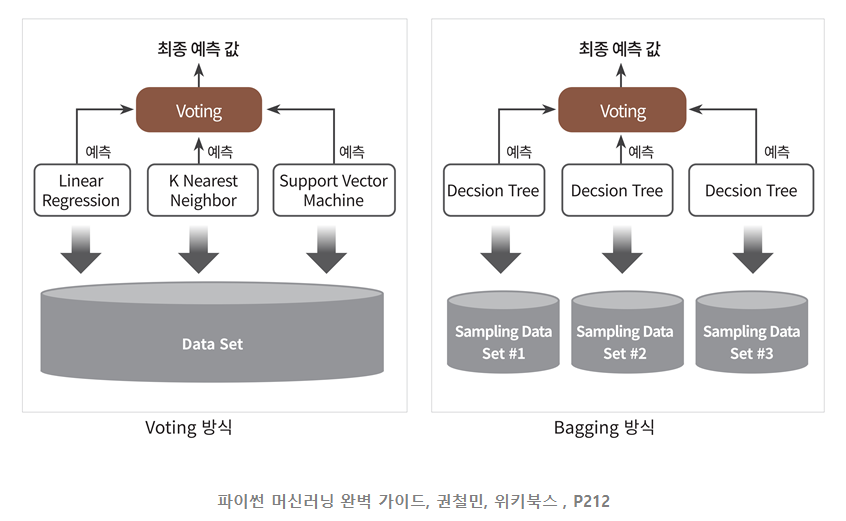

샘플링 방식 : 부트 스트래핑 분할 방식
- 개별 Classifier에게 데이터를 샘플링해서 추출하는 방식
- 각 샘플링된 데이터 내에는 중복 데이터 포함
- (교차 검증에서는 데이터 세트 간에 중복 허용하지 않음)

https://swalloow.github.io/bagging-boosting/

### 부스팅(Boosting)
- 여러 개의 분류기가 **순차적으로 학습 수행**하되
- 앞에서 학습한 분류기가 예측이 틀린 데이터에 대해서는 올바르게 예측할 수 있도록
    - 다음 분류기에게는 **가중치(weight)를 부여하면서** 샘플을 전달 
    - 가중치를 포함한 학습과 예측을 진행하는 방식
- 예측 성능이 뛰어나 앙상블 학습 주도
- boost : 밀어 올림
    
**대표적인 부스팅 모듈**
- Gradient Boost : 학습시간이 오래 걸림
- XGBoost(eXtra Gradient Boost) : 학습시간을 개선 했지만 학습 시간이 오래 걸림
- LightGBM(Light Gradient Boost) : 학습시간을 개선 시간측면에서 제일 우수함
    - 대용량의 데이터에 사용해야 함
        - 샘플 10000개 이상일 경우 최적의 성능

#### 보팅 유형(여러 모델의 예측을 결합하는 방법)
- 하드 보팅
- 소프트 보팅

#### 하드 보팅 (Hard Voting)
- 다수결 원칙과 유사
- 예측한 결과값들 중에서 
- 다수의 분류기가 결정한 예측값을
- 최종 보팅 결과값으로 선정

#### 소프트 보팅 (Soft Voting)
- 분류기들의 레이블 값 결정 확률을 평균내서
- 확률이 가장 높은 레이블 값을
- 최종 보팅 결과값으로 선정
- 일반적으로 소프트 보팅이 예측 성능이 좋아서 더 많이 사용

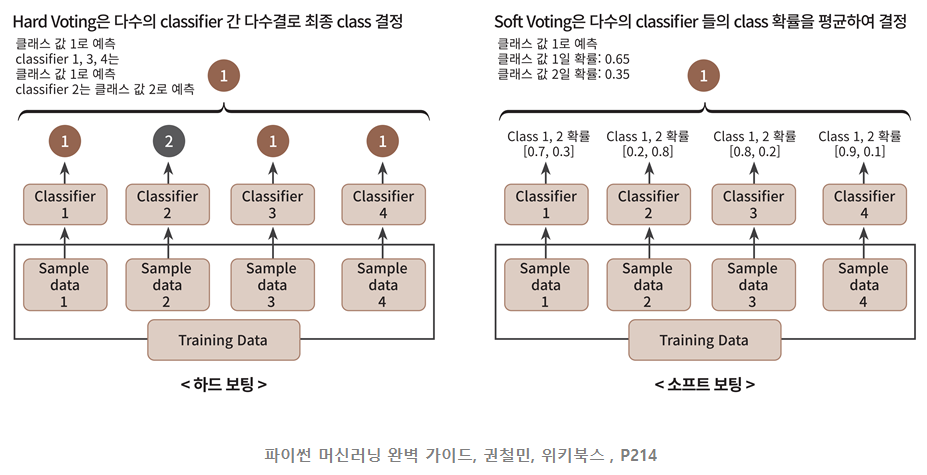

### Voting Classifier

### 보팅 방식의 앙상블 예제 : 위스콘신 유방암 데이터 세트 예측 분석  

**위스콘신 유방암 데이터 세트**  

- 유방암의 악성종양, 양성종양 여부를 결정하는 이진 분류 데이터 세트
- 종양의 크기, 모양 등의 형태와 관련한 많은 피처 포함
- 사이킷런의 보팅 양식의 앙상블을 구현한 VotingClassifier 클래스를 이용해서 보팅 분류기 생성  
- load_breast_cancer() 함수를 통해 위스콘신 유방암 데이터 세트 생성
- 로지스틱 회귀와 KNN 기반으로 소프트 보팅 방식으로 보팅 분류기 생성


### 데이터 준비

In [1]:
import pandas as pd

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
cancer = load_breast_cancer()

data_df = pd.DataFrame(cancer.data, columns = cancer.feature_names)
data_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# cancer.target
data_df.shape

(569, 30)

- 개별 모델 : 로지스틱 회귀/ KNN   

**학습/예측/평가 후 성능 비교**

로지스틱 회귀
- 선형 회귀 방식을 분류에 적용한 알고리즘
- 선형 회귀 방식을 기반으로 하되
- 시그모이드 함수를 이용해 분류 수행

K- 최근접 이웃 알고리즘 (K-Nearest Neighbor) 
- 가장 직관적이고 간단
- 주변의 더 많은 데이터 범주로 분류하는 방식

In [4]:
# 1. 개별 모델 객체 인스턴스 생성  
lr_clf = LogisticRegression(solver='liblinear')
# solver : 회귀 계수를 찾는 문제에 사용하는 함수 설정 하이퍼파라미터
# 기본값이 liblinear 함수 였는데 업데이트되면서 기본값이 변경
# liblinear : L1, L2 규제를 모두 지원, 데이터 양이 적은경우에도 좋은 성능
knn_clf = KNeighborsClassifier(n_neighbors=8)

VotingClassifier 클래스의 주요 생성 인자
- estimators : 리스트 값으로 보팅에 사용될 여러 개(list형식)의 Classifier 객체들을 튜플 형식으로 입력 받음
    - [('LR',lr_clf),('KNN',knn_clf)]
- voting : 보팅 방식 - hard/soft (디폴트 : hard) 

In [5]:
# 2. 개별 모델을 소프트 보팅 기반의 앙상블 모델로 구현한 분류기 인스턴스 생성
vo_clf = VotingClassifier(estimators=[('LR',lr_clf),('KNN',knn_clf)], voting='soft')

In [6]:
# 3. 데이터세트 분리
# 데이터 세트 분리
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, 
                                                        test_size=0.2 , random_state= 156)

In [7]:
# 4. 모델학습
vo_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('LR', LogisticRegression(solver='liblinear')),
                             ('KNN', KNeighborsClassifier(n_neighbors=8))],
                 voting='soft')

In [8]:
pred = vo_clf.predict(X_test)
# 평가
print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test , pred)))

Voting 분류기 정확도: 0.9561


In [9]:
# 로지스틱 회귀와 KNN 각 개별 모델로 학습/예측/평가
classifiers = [lr_clf, knn_clf]

for cls in classifiers :
    cls.fit(X_train, y_train) # 단일 모델 학습
    pred = cls.predict(X_test)
    name = cls.__class__.__name__ # 개별 모델 클래스명 추출
    print('{0}정확도 : {1:.4f}'.format(name, accuracy_score(y_test, pred)))

LogisticRegression정확도 : 0.9474
KNeighborsClassifier정확도 : 0.9386


#### 결론 : 보팅을 통해서 개별 모델들을 합치면 좋아질 수 있는 가능성이 있고, 모델 방향을 선택할 수 있음

## 배깅(Bagging) 학습 유형

- 대표적인 알고리즘 : 랜덤포레스트 알고리즘  

    - 모델로 결정트리 모델을 사용함
        - 결정트리 : 쉽고 직관적인 분류 기준을 갖고있음
            - 단점 : 데이터를 과학게 학습 - 과적합
    - 결정트리 수십개~ 수천개의 많은 분류기를 결합해 다양한 상황을 학습하게 해서 과적합의 단점을 극복하고 있음

### Random Forest  

- 앙상블 알고리즘 중 **수행속도**가 빠르다
- 다양한 영역에서 높은 예측성능을 보인다
- 기반 알고리즘 : 결정트리

- **앙상블 알고리즘은 수행속도가 큰 이슈였음**

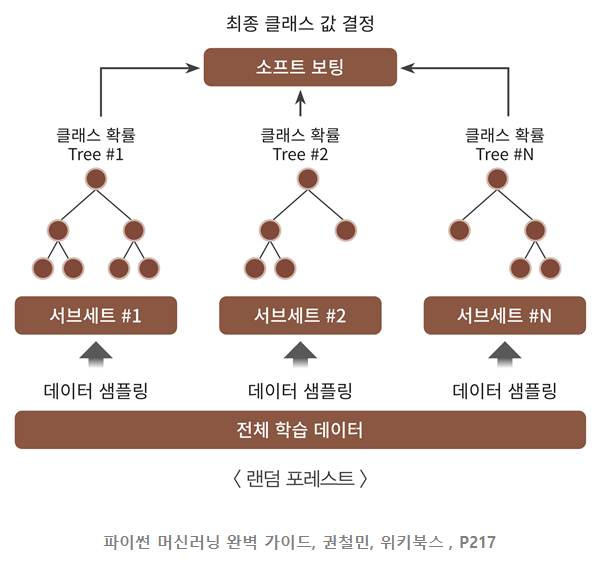

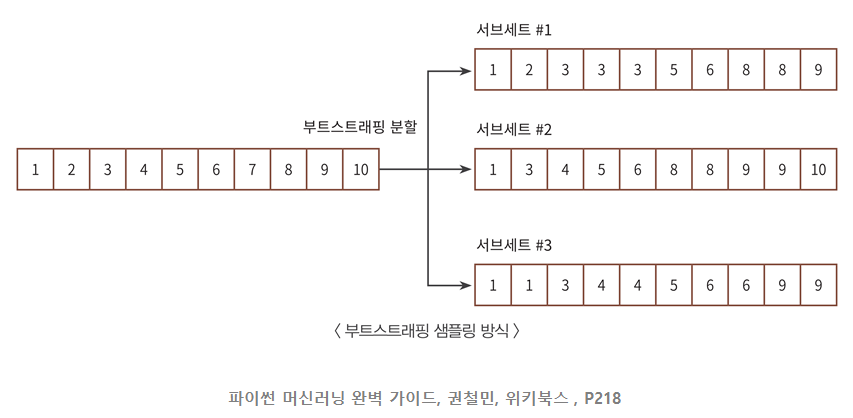

## 랜덤 포레스트 예제
- 사용자 행동 인식 데이터 세트를 
    - 갤럭시 워치를 몸에 부착한 여러명의 사람들이 걷기, 계단오르내리기, 뛰기, 눕기, 앉등의 행동을 하면서 나타난 데이터를 수집해 놓은 데이터
        - 위치관련한 데이터들
- 사이킷런의 RandomForestClassifier 클래스를 이용해 예측 수행

**사용자 행동 인지 데이터 세트 로딩**

In [11]:
X_train = pd.read_csv('./data/human_X_train.csv')
X_test = pd.read_csv('./data/human_X_test.csv')
y_train = pd.read_csv('./data/y_train.txt',sep='\s+',header=None,names=['action'])
y_test = pd.read_csv('./data/y_test.txt',sep='\s+',header=None,names=['action'])

In [31]:
X_train.head()
X_train.shape
set(y_train['action']) # 사용자 행동 6개에 대해서 하나의 행동으로 분류되어있음

(7352, 561)

#### 랜덤포레스트 이용 학습/예측/평가

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

-  human dataset의 단일트리 정확도
    - 0.85 정도 나옴

In [22]:
rf_clf = RandomForestClassifier(random_state=0, n_estimators=100)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy))

랜덤 포레스트 정확도: 0.9253


#### 결과 : 정확도는 향상 되었지만 수행속도가 좋은편이 아님

**GridSearchCV 로 교차검증 및 하이퍼 파라미터 튜닝**
- 앞의 사용자 행동 데이터 세트 그대로 사용
- 튜닝 시간을 절약하기 위해 
    - n_estimators=100
    - cv=2

#### n_estimators : 결정 트리의 개수. 디폴트 10
- 많이 설정할수록 좋은 성능을 기대할 수 있지만
- 계속 증가시킨다고 무조건 향샹되는 것은 아님
    - 너무 증가시키면 과적합 발생할 수 있음
- 또 증가시킬수록 학습 수행 시간이 오래 걸림
    - 환경이 가능하면 n_jobs=-1로 설정하면 모든 cpu 코어를 이용해 학습

In [26]:
from sklearn.model_selection import GridSearchCV

# 테스트해볼 데이터(파라미터 값)를 많이 넣으면 기하급수적으로 늘어난다
params ={
    'n_estimators' : [100],
    'max_depth' : [6,8,10,12],
    'min_samples_leaf' : [8,12,18],
    'min_samples_split' : [8, 16, 20] #4X4X3 : 36번
}
rf_clf = RandomForestClassifier(random_state=0, n_jobs=-1)

grid_cv = GridSearchCV(rf_clf, param_grid=params, cv=2, n_jobs=-1)
grid_cv.fit(X_train, y_train)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print('최고 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:
 {'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 100}
최고 예측 정확도: 0.9180


- 파라미터튜닝이 늘어날수록 학습시간은 더 오래 걸린다

#### 튜닝된 하이퍼파라미터로 재 학습/예측/평가 - 분류기 수를 확장

In [28]:
rf_clf1 = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=8,
                    min_samples_split=8, random_state=0, n_jobs=-1)
rf_clf1.fit(X_train, y_train)
pred=rf_clf1.predict(X_test)
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test , pred)))

예측 정확도: 0.9196


### n_estimaotrs 수
- 100일때 : 0.9196
- 500일때 : 0.9175 로 더 감소함
    - 모델수를 늘리는게 무조건성능을 향상시키지는 않는다

### 개별 feature들의 중요도 시각화

- feature_importance_ 속성을 이용해서 피처중요를 알 수 있음

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
ftr_import = rf_clf1.feature_importances_
top_20 = pd.Series(ftr_import, index=X_train.columns).sort_values(ascending=False)[:20]
top_20

angle(X,gravityMean)              0.036706
tGravityAcc-mean()-Y              0.030420
tGravityAcc-min()-X               0.028295
tGravityAcc-energy()-X            0.027252
angle(Y,gravityMean)              0.026723
tGravityAcc-mean()-X              0.025741
tGravityAcc-max()-X               0.023927
tGravityAcc-max()-Y               0.023453
tGravityAcc-min()-Y               0.023310
fBodyAccJerk-bandsEnergy()-1,8    0.019908
tGravityAcc-energy()-Y            0.016938
tGravityAcc-arCoeff()-Z,2         0.014282
fBodyAccMag-energy()              0.013845
tBodyAccJerk-entropy()-X          0.013629
fBodyAccMag-mad()                 0.012437
tBodyAcc-max()-X                  0.012114
tGravityAcc-max()-Z               0.011312
angle(Z,gravityMean)              0.010401
tGravityAcc-energy()-Z            0.009488
fBodyAcc-entropy()-X              0.009419
dtype: float64

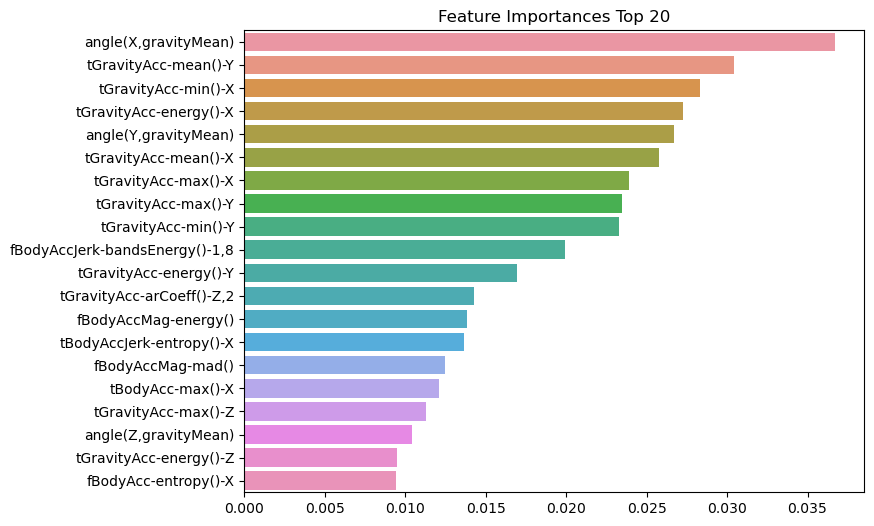

In [34]:
plt.figure(figsize=(8,6))
plt.title('Feature Importances Top 20')
sns.barplot(x=top_20, y=top_20.index)
plt.show()

### 랜덤포레스트등의 앙상블 모델을 활용하면 
- 일반적으로 성능 향상을 기대할 수 있다
- 랜덤포레스트경우 트리수(모델수)를 늘린다고 무조건 성능이 향상되지는 않음
    - 과적합 발생가능성이 높아짐
- 트리수는 고정시키고(100이상을 사용)
    - 하이퍼 파라미터 튜닝으로 최적 하이퍼 파라미터 찾고
    - 트리수를 튜닝